# A-RoF transmission

In [1]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent)

sys.path.append(project_path)

In [2]:
import pickle 
import torch as th
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal             import welch, firwin
from tqdm.notebook            import tqdm
from tabulate                 import tabulate

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, finddelay, decimate, clockSamplingInterp
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters

from dpd.channel_models import RoF_channel
from dpd.utils import calcACLR, applyDPD
from dpd.nn import trainNN, trainMP

In [3]:
font = {'size':16}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - OFDM signal generation

In [133]:
# Parâmetros de modulação
modOrder  = 64                 # Modulation order
constType = 'qam'              # Constellation format
Rb = 5e9                       # Bitrate
SpS = 32

# OFDM parameters
paramOFDM = parameters()
paramOFDM.G   = 32              
paramOFDM.SpS = SpS

paramOFDM.Nfft = 2**10
paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)
paramOFDM.pilotCarriers = np.linspace(0, paramOFDM.Nfft - 1, 32, dtype = np.int64)

Nz = len(paramOFDM.nullCarriers)
Np = len(paramOFDM.pilotCarriers)
Ni = paramOFDM.Nfft - Nz - Np
numOFDMframes = 100

In [134]:
# Bits generation
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

# Symbols modulation
symbTx = modulateGray(bits, modOrder, constType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [135]:
# OFDM signal generation
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

Rs = Rb / ( Ni / (paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder))
Fs = Rs * paramOFDM.SpS

t = np.arange(0, sigTx.size)*1/Fs
t_CP   = paramOFDM.SpS * paramOFDM.G * (1/Fs)
t_symb = paramOFDM.SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [136]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Sampling rate', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Symbol rate', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Bit rate', 'Rb', f'{Rb*1e-9:.2f} GHz'],
         ['Ordem da constelação', 'M', f'{modOrder}'],
         ['Nfft', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Cyclic prefix length', 'G', f'{paramOFDM.G}'],
         ['Number of information subcarriers', 'Ni', f'{Ni}'],
         ['Number of pilot subcarriers', 'Np', f'{Np}'],
         ['Number of null subcarriers', 'Nz', f'{Nz}'],
         ['Subcarriers spacing', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-3:.2f} kHz'],
         ['OFDM symbol period', 'T_symb', f'{1e6*t_symb:.2f} us'],
         ['Cyclic prefix duration', 'T_CP', f'{1e6*t_CP:.2f} us'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═══════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                          │ Parâmetro   │ Valor            │
╞═══════════════════════════════════╪═════════════╪══════════════════╡
│ Sampling rate                     │ Fs          │ 28.42 Gsamples/s │
├───────────────────────────────────┼─────────────┼──────────────────┤
│ Symbol rate                       │ Rs          │ 0.89 Gsymb/s     │
├───────────────────────────────────┼─────────────┼──────────────────┤
│ Bit rate                          │ Rb          │ 5.00 GHz         │
├───────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação              │ M           │ 64               │
├───────────────────────────────────┼─────────────┼──────────────────┤
│ Nfft                              │ Nfft        │ 1024             │
├───────────────────────────────────┼─────────────┼──────────────────┤
│ Cyclic prefix length              │ G           │ 32               │
├─────

### 2 - A-RoF channel

In [137]:
# MZM parameters
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi*0.5
paramMZM.P_laser = 0
paramMZM.Pin_MZM = 17

# RF parameters
paramRF = parameters()
paramRF.fc_e = 3.55e9
paramRF.bw = Rs
paramRF.Fs = Fs

# Optical fiber parameters
paramFiber = parameters()
paramFiber.L = 20
paramFiber.alpha = 0.2
paramFiber.D = 16
paramFiber.Fc = 193.1e12
paramFiber.Fs = Fs

# Photodiode parameters
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

# PA parameters
paramPA = parameters()
paramPA.model_name = "modified_rapp"
paramPA.g = 16
paramPA.x_sat = 1.9
paramPA.sigma_p = 1.1
paramPA.alpha = -345
paramPA.beta = 0.17
paramPA.q = 4

In [138]:
paramRoF = parameters()
paramRoF.paramMZM = paramMZM
paramRoF.paramRF = paramRF
paramRoF.paramFiber = paramFiber
paramRoF.paramPD = paramPD
paramRoF.paramPA = paramPA

sigRx_PA = RoF_channel(sigTx, paramRoF, filter_numtaps = 4096)

In [139]:
hlp = firwin(4096, Rs/1.75, fs = Fs)
sigRx = firFilter(hlp, sigRx_PA)

delay = finddelay(sigRx, sigTx)
sigRx = np.roll(sigRx, -delay)

rot = np.mean(sigTx/sigRx)
sigRx = rot/np.abs(rot)*sigRx

# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = paramOFDM.SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx, paramDec).ravel()
symbRx = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.01100 
SNR = 19.677 dB
EVM = 9.804 %


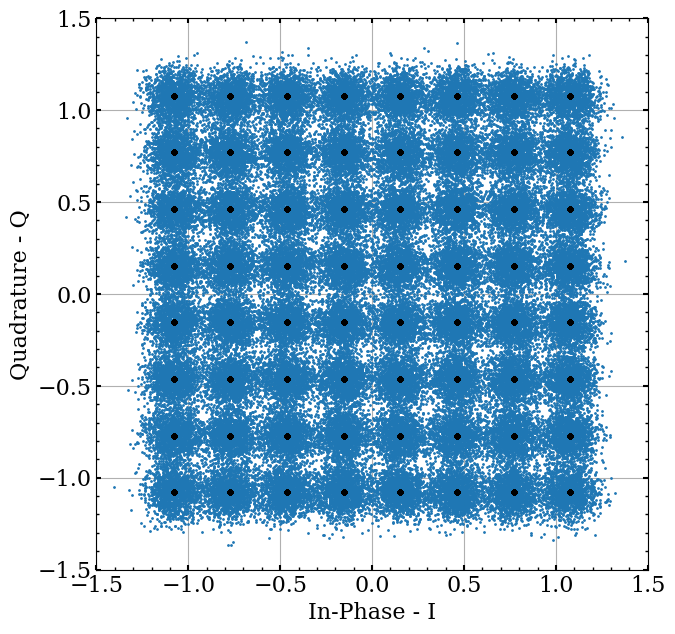

In [141]:
discard = 100
index = np.arange(discard, symbTx.size - discard)
BER, SER, SNR = fastBERcalc(symbRx[index], symbTx[index], modOrder, constType)

EVM = np.sqrt(calcEVM(symbRx, modOrder, constType))*100

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB\nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

plotConst(symbTx, symbRx, axs_lim = 1.5)

In [159]:
def plotSpec(freq, P_sigTx, P_sigRx, label, x_lim = [-2, 2], y_lim = [-125, -80], freq_unit = "GHz", show = True, save = False, file_path = None):
    if freq_unit == "THz":
        freq_norm = 1e12
    
    elif freq_unit == "GHz":
        freq_norm = 1e9
    
    elif freq_unit == "MHz":
        freq_norm = 1e6
        
    elif freq_unit == "KHz":
        freq_norm = 1e3
    
    else:
        freq_norm = 1

    fig, axs = plt.subplots(1, 1, figsize = (7, 5))
    axs.plot(freq/freq_norm, 10*np.log10(P_sigTx), lw = 2)
    
    if type(P_sigRx) == list:
        for i, P_sig in enumerate(P_sigRx):
            axs.plot(freq/freq_norm, 10*np.log10(P_sig), lw = 2, label = label[i])

    else:
        axs.plot(freq/freq_norm, 10*np.log10(P_sigRx), lw = 2, label = label)
    
    
    axs.set_xlim(x_lim[0], x_lim[1])
    axs.set_ylim(y_lim[0], y_lim[1])
    
    axs.set_ylabel("Power Spectral Density [dB/Hz]")
    axs.set_xlabel(f"Frequency [{freq_unit}]")
    
    axs.minorticks_on()
    axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
    axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

    axs.legend(framealpha = 1)
    
    plt.grid()    
    plt.tight_layout()
    
    if save:
        plt.savefig(file_path)
    
    if not(show):
        plt.close()

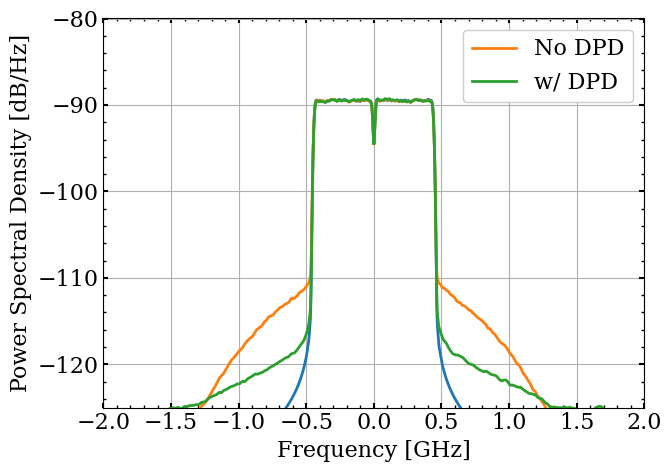

In [161]:
plotSpec(freq, P_sigTx, [P_sigRx_PA, P_sigRx_PA_DPD], label = ["No DPD", "w/ DPD"])

SigTx - ACLR = -31.277 dB
SigRx PA w/o DPD - ACLR = -24.984 dB


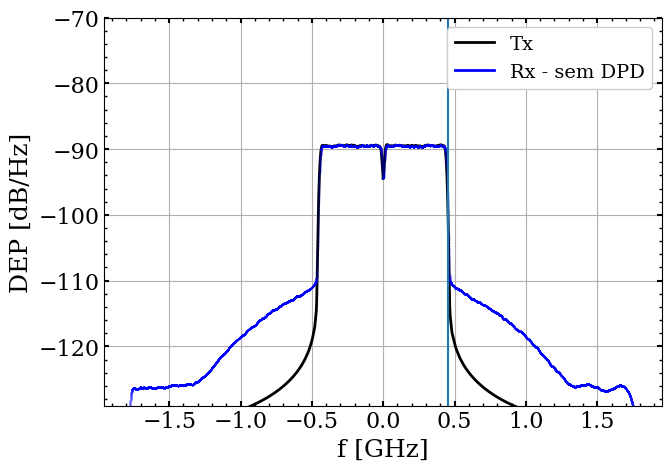

In [78]:
freq, P_sigTx    = welch(pnorm(sigTx)[0::paramOFDM.SpS//4], fs = 4*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA = welch(pnorm(sigRx_PA)[0::paramOFDM.SpS//4], fs = 4*Rs, nfft = 16*1024, return_onesided = False)

print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, Rs/2, 10e6):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, Rs/2, 10e6):.3f} dB")

fig, axs = plt.subplots(1, 1, figsize = (7, 5))

axs.plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA), "o", lw = 2, color = "b", ms = 0.1)

# Trick to improve legends
axs.plot(1, 1, lw = 2, color = "b", label = "Rx - sem DPD")

#axs.set_xlim(-0.2, 0.2)
axs.set_ylim(-129, -70)

axs.set_ylabel("DEP [dB/Hz]", fontsize = 18)
axs.set_xlabel("f [GHz]", fontsize = 18)
axs.legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

axs.axvline( (0.5*Rs + 10e6) /1e9)

plt.tight_layout()
#plt.savefig("sig_freq_mpDPD.pdf")

In [79]:
SpS_DPD = 4
Fs_DPD = Fs * SpS_DPD / SpS

hlp = firwin(4096, SpS_DPD*Rs/2, fs = Fs)

sigRef = clockSamplingInterp(pnorm(firFilter(hlp, sigTx).reshape(-1, 1)), Fs, Fs_DPD).ravel()
sigIn  = clockSamplingInterp(pnorm(firFilter(hlp, sigRx_PA).reshape(-1, 1)), Fs, Fs_DPD).ravel()

delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

### 3 - Transmission with DPD-ARVTDNN

In [16]:
paramModel = parameters()
paramModel.model_name = "ARVTDNN"
paramModel.K = 3
paramModel.M = 3
paramModel.hidden_layers = [16, 8]
paramModel.activation = "relu"

paramTrain = parameters()
paramTrain.trainTestFrac = 0.75
paramTrain.batchSize     = 1_000
paramTrain.shuffle       = False
paramTrain.adaptLearningRatio = True
paramTrain.lr      = 5e-3
paramTrain.epochs  = 500
paramTrain.pgrsBar = True
paramTrain.device  = "cuda" # "cpu"

model, trainLoss, testLoss = trainNN(th.from_numpy(sigIn[0:50_000]).to(paramTrain.device).type(th.complex64),  \
                                     th.from_numpy(sigRef[0:50_000]).to(paramTrain.device).type(th.complex64), \
                                     paramTrain, paramModel)

  0%|          | 0/500 [00:00<?, ?it/s]

In [82]:
sigTx_DPD, gain_DPD = applyDPD(sigTx, model, Rs, Fs, Fs_DPD, paramTrain, paramModel)
paramRoF.paramMZM.Pin_MZM = 17 + gain_DPD

sigRx_PA_DPD = RoF_channel(sigTx_DPD, paramRoF, filter_numtaps = 4096)

In [86]:
# Filtering and delay correction
hlp = firwin(4096, Rs/1.75, fs = Fs)
sigRx_DPD = firFilter(hlp, sigRx_PA_DPD)

delay = finddelay(sigRx_DPD, sigTx)
sigRx_DPD = np.roll(sigRx_DPD, -delay)

rot = np.mean(sigTx/sigRx_DPD)
sigRx_DPD = rot/np.abs(rot)*sigRx_DPD

# Decimation
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx_DPD, paramDec).ravel()
symbRx_DPD  = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00040 
EVM = 3.901 %


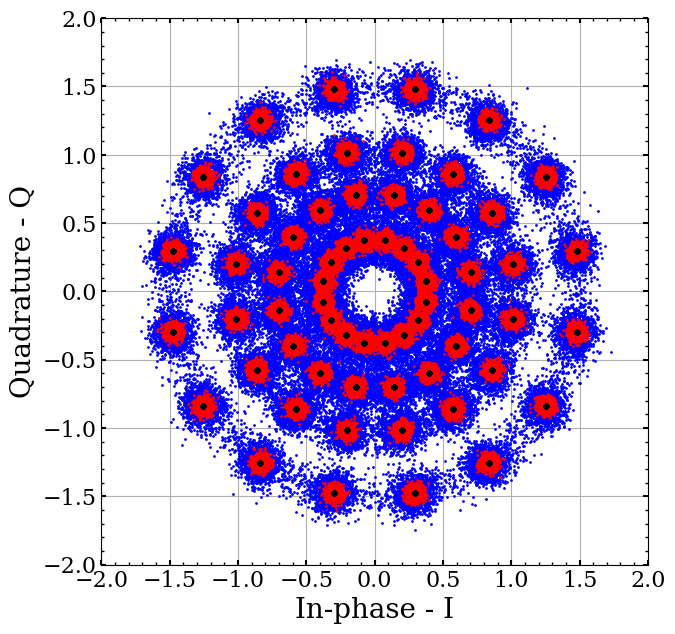

In [98]:
discard = 100
index = np.arange(discard, symbTx.size - discard)
BER, _, _ = fastBERcalc(symbRx_DPD[index], symbTx[index], modOrder, constType)

EVM = np.sqrt(calcEVM(symbRx_DPD[index], modOrder, constType))*100

print(f"BER = {BER[0]:.5f} \nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD = pnorm(symbRx_DPD)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx.real, symbRx.imag, "o", color = "b", ms = 1, label = "SymbRx - DPD")
axs.plot(symbRx_DPD.real, symbRx_DPD.imag, "o", color = "r", ms = 1, label = "SymbRx - DPD")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadrature - Q", fontsize = 20)
axs.set_xlabel("In-phase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-2, 2)
axs.set_ylim(-2, 2)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
plt.grid()

plt.tight_layout()

SigTx - ACLR = -31.277 dB
SigRx PA w/o DPD - ACLR = -24.984 dB
SigRx PA w/ DPD - ACLR = -28.897 dB


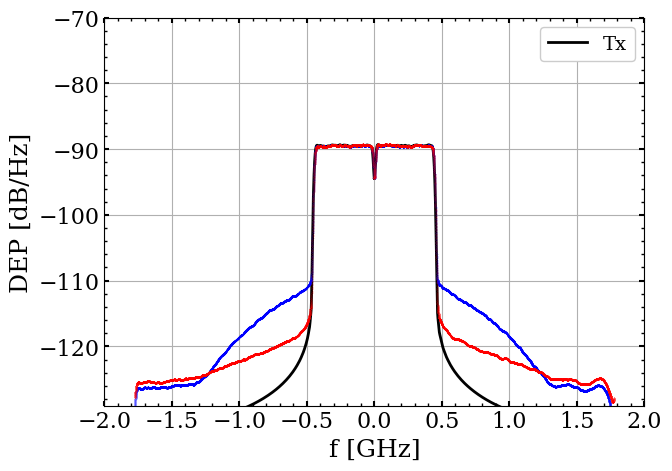

In [91]:
freq, P_sigTx    = welch(pnorm(sigTx)[0::SpS//SpS_DPD], fs = 4*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA = welch(pnorm(sigRx_PA)[0::SpS//SpS_DPD], fs = 4*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD = welch(pnorm(sigRx_PA_DPD)[0::SpS//SpS_DPD], fs = 4*Rs, nfft = 16*1024, return_onesided = False)

print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, Rs/2, 10e6):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, Rs/2, 10e6):.3f} dB")
print(f"SigRx PA w/ DPD - ACLR = {calcACLR(P_sigRx_PA_DPD, freq, Rs/2, 10e6):.3f} dB")

fig, axs = plt.subplots(1, 1, figsize = (7, 5))

axs.plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA), "o", lw = 2, color = "b", ms = 0.1)
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD), "o", lw = 2, color = "r", ms = 0.1)

axs.set_xlim(-2, 2)
axs.set_ylim(-129, -70)

axs.set_ylabel("Power Spectral Density [dB/Hz]", fontsize = 18)
axs.set_xlabel("Frequency [GHz]", fontsize = 18)
axs.legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

#axs.axvline( (0.5*Rs + 10e6) /1e9)

plt.tight_layout()
#plt.savefig("sig_freq_mpDPD.pdf")

In [59]:
paramModel = parameters()
paramModel.model_name = "ETDNN"
paramModel.N = 10
paramModel.M = 1
paramModel.activation = "relu"

paramTrain = parameters()
paramTrain.trainTestFrac = 0.75
paramTrain.batchSize     = 1_000
paramTrain.shuffle       = False
paramTrain.adaptLearningRatio = True
paramTrain.lr      = 5e-3
paramTrain.epochs  = 500
paramTrain.pgrsBar = True
paramTrain.device  = "cuda" # "cpu"

model, trainLoss, testLoss = trainNN(th.from_numpy(sigIn[0:50_000]).to(paramTrain.device).type(th.complex64),  \
                                     th.from_numpy(sigRef[0:50_000]).to(paramTrain.device).type(th.complex64), \
                                     paramTrain, paramModel)

  0%|          | 0/500 [00:00<?, ?it/s]

In [26]:
paramModel = parameters()
paramModel.model_name = "ETDKAN"
paramModel.N = 1
paramModel.M = 1
paramModel.k = 2
paramModel.grid = 2
paramModel.seed = 0

paramTrain = parameters()
paramTrain.trainTestFrac = 0.75
paramTrain.batchSize     = 1_000
paramTrain.shuffle       = False
paramTrain.adaptLearningRatio = True
paramTrain.lr      = 5e-3
paramTrain.epochs  = 100
paramTrain.pgrsBar = True
paramTrain.device  = "cuda" # "cpu"
paramTrain.symbolicEpoch = 50

model, trainLoss, testLoss = trainNN(th.from_numpy(sigIn[0:50_000]).to(paramTrain.device).type(th.complex64),  \
                                     th.from_numpy(sigRef[0:50_000]).to(paramTrain.device).type(th.complex64), \
                                     paramTrain, paramModel)

  0%|          | 0/100 [00:00<?, ?it/s]

In [81]:
M = 2
P = 3

paramModel = parameters()
paramModel.model_name = "MP"
paramModel.M = M
paramModel.P = P

paramTrain = parameters()
paramTrain.epochs = 5
paramTrain.mu  = 1e-3
paramTrain.lbd = 0.9999
paramTrain.S   = np.eye(paramModel.P*(paramModel.M + 1), dtype = complex)*5e-2
paramTrain.alg = "RLS"
paramTrain.pgrsBar = True

model, trainLoss = trainMP(sigIn[0:50_000], sigRef[0:50_000], paramTrain, paramModel)

  0%|          | 0/5 [00:00<?, ?it/s]